<a href="https://colab.research.google.com/github/cosmicurvy/amazon-reviews-nlp/blob/main/notebooks/DistilBERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip uninstall -y transformers
!pip install transformers==4.48.0 tf-keras

In [3]:
# importing the required libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import tensorflow as tf
import transformers
from transformers import DistilBertTokenizer, TFDistilBertForSequenceClassification
from tf_keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy

# to ingore warnings
import warnings; warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("/content/drive/MyDrive/Sentiment-Classification/amazon_reviews.csv")
df.sample(5)

,title,text,rating
42408,"What an excellent sounding guitar, Well Built ...","What an amazing sounding guitar! Well built, c...",5
43747,Is is durable. I do not want to have to purcha...,I love it so far.,2
12586,"Great mics, in my opinion.",I don't rate quality of sound much due to not ...,5
4761,Good Strap for good guitar ),Good quality leather.<br />I use it with lots ...,5
20454,BUYER'S BEWARE!,Broke literally within the first 5 mins of ope...,1


In [5]:
df.shape

(50000, 3)

In [6]:
print(df.isnull().sum())
df.dropna(inplace=True)
print("\n")
print(df.shape)

title     6
text      5
rating    0
dtype: int64


(49989, 3)


- The function below labels reviews with ratings of 1 and 2 as 0 (negative), reviews with ratings of 3 as 1 (neutral) and reviews with ratings of 4 and 5 as 1 (positive).

In [7]:
# function to get the sentiment for each review
def get_sentiment(rate):
  if rate in [1, 2]:
    return 0
  elif rate == 3:
    return 1
  else:
    return 2
df['sentiment'] = df['rating'].apply(get_sentiment)

In [8]:
df.sample(5)

,title,text,rating,sentiment
42310,Five Stars,GREAT STRAP!!!!!! Will last forever!!!!,5,2
27356,Great Value,Cable Matters products have certainly impresse...,5,2
26399,WORTH YOUR MONEY,Best microphone I’ve ever owned,5,2
3297,but once you have been playing with it for a w...,"There is a bit of a learning curve, but once y...",5,2
42583,too much feedback .,this micprophone too much feedback and sound n...,3,1


In [9]:
df.sentiment.value_counts()

,count
sentiment,
2,39684
0,6874
1,3431


- Tha dataset is highly imbalanced.

In [10]:
# spliting the training and test sets
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['sentiment'], test_size=0.2, random_state=35)

## Model Training

- DistilBERT is a compressed version of BERT that distils BERT's knowledge into a smaller model with fewer parameters, lower memory usage and significantly faster inference.

- In this project, the DistilBERT tokenizer is used to prepare the text and the DistilBERT model is used for sentiment classification.

In [11]:
model_name = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = TFDistilBertForSequenceClassification.from_pretrained(model_name, num_labels=3)

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_layer_norm.weight', 'vocab_projector.bias', 'vocab_transform.bias', 'vocab_layer_norm.bias', 'vocab_transform.weight']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

In [12]:
MAX_LEN = 128
BATCH_SIZE = 32
EPOCHS = 3

In [13]:
# tokenizing and encoding the training and test sets
train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LEN,
    return_tensors='tf'
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LEN,
    return_tensors='tf'
)

In [14]:
print(train_encodings['input_ids'][0])

tf.Tensor(
[  101  2307  2307 22980 11875  2061  2521   999   999   999   102     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0], shape=(128,), dtype=int32)


In [15]:
print(train_encodings['attention_mask'][0])

tf.Tensor(
[1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0], shape=(128,), dtype=int32)


- `attention_mask` ignores padding values.

In [16]:
len(X_train.tolist())

39991

In [17]:
len(y_train.tolist())

39991

- Tokenizer outputs and labels are converted into a tensorflow dataset for model input.

In [18]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        {
            'input_ids' : train_encodings['input_ids'],
            'attention_mask' : train_encodings['attention_mask']
        },
        y_train
    )

)


test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        {
            'input_ids' : test_encodings['input_ids'],
            'attention_mask' : test_encodings['attention_mask']
        },
        y_test
    )

)

- `shuffle` adds randomness to the training data.

- `drop_remainder=True` ensures that each batch contains 32 samples by dropping leftover data at end of the epoch that does not fit into a full fatch.

In [19]:
train_dataset = (train_dataset.shuffle(1000).batch(BATCH_SIZE, drop_remainder=True))

In [20]:
# optimizer
optimizer = Adam(learning_rate=5e-5)
# loss
loss = SparseCategoricalCrossentropy(from_logits=True)

In [21]:
model.compile(optimizer=optimizer,
              loss = loss,
              metrics= 'accuracy')

model.summary()

Model: "tf_distil_bert_for_sequence_classification"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 distilbert (TFDistilBertMa  multiple                  66362880  
 inLayer)                                                        
                                                                 
 pre_classifier (Dense)      multiple                  590592    
                                                                 
 classifier (Dense)          multiple                  2307      
                                                                 
 dropout_19 (Dropout)        multiple                  0 (unused)
                                                                 
Total params: 66955779 (255.42 MB)
Trainable params: 66955779 (255.42 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [22]:
# training the model for three epochs
history = model.fit(train_dataset, epochs = EPOCHS)

Epoch 1/3
1249/1249 [==============================] - 510s 384ms/step - loss: 0.3362 - accuracy: 0.8780
Epoch 2/3
1249/1249 [==============================] - 478s 383ms/step - loss: 0.2390 - accuracy: 0.9115
Epoch 3/3
1249/1249 [==============================] - 477s 382ms/step - loss: 0.1780 - accuracy: 0.9352


In [23]:
history.history

{'loss': [0.3361615538597107, 0.23904387652873993, 0.17804202437400818],
 'accuracy': [0.878002405166626, 0.9115292429924011, 0.9351731538772583]}

In [24]:
test_dataset = test_dataset.batch(BATCH_SIZE)

In [25]:
loss, acc = model.evaluate(test_dataset)
print("Loss on test data: ", loss)
print("Accuracy on test data: ", acc)

313/313 [==============================] - 48s 141ms/step - loss: 0.3664 - accuracy: 0.8903
Loss on test data:  0.3663882315158844
Accuracy on test data:  0.8902780413627625


- After training for three epochs, the DistilBERT Model achieved 89% accuracy on the test data.

313/313 [==============================] - 46s 141ms/step


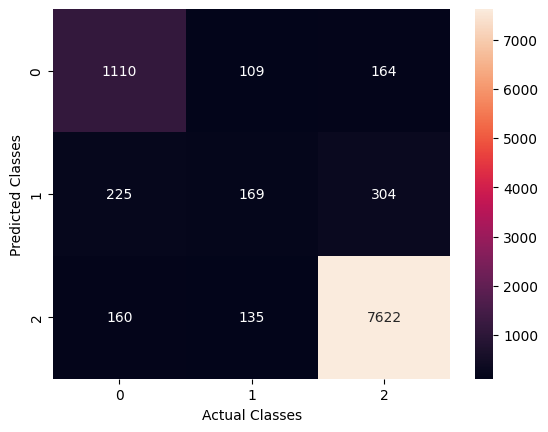

In [26]:
# confusion matrix
predictions = model.predict(test_dataset)
logits = predictions.logits
predicted_labels = np.argmax(logits, axis=1)

sns.heatmap(confusion_matrix(y_test, predicted_labels), annot=True, fmt='.0f')
plt.xlabel("Actual Classes")
plt.ylabel("Predicted Classes")
plt.show()

In [27]:
# function to predict the sentiment of unseen reviews
def make_prediction(text):
  input = tokenizer(text,
                     truncation=True,
                     padding=True,
                     return_tensors="tf"
                     )
  pred = model.predict(input)
  logits = pred['logits']

  probs = tf.nn.softmax(logits)

  predicted_cls = np.argmax(probs, axis=1)[0]

  if predicted_cls == 0:
    return "Negative"
  elif predicted_cls == 1:
    return "Neutral"
  else:
    return "Positive"

In [32]:
# reviews for testing
text1 = "Well made, good fit & finish, does the job!  If you don't want to spend the money for an enclosed rack case, this is a good alternative."
text2 = "The guitar is ok for beginners but I had to immediately take it in for repairs when I got it because the neck was warped from however they had it stored so in the long run I could have just spent a little extra $$ and saved a few trips to the music store"
text3 = "Lost its tuning every single day . Had to return it."

In [33]:
make_prediction(text1)

1/1 [==============================] - 0s 152ms/step


'Positive'

In [34]:
make_prediction(text2)

1/1 [==============================] - 0s 76ms/step


'Neutral'

In [35]:
make_prediction(text3)

1/1 [==============================] - 0s 95ms/step


'Negative'

In [36]:
# saving the tokenizer and model
tokenizer.save_pretrained('/content/drive/MyDrive/Sentiment-Classification/distilbert_tokenizer.zip')
model.save_pretrained('/content/drive/MyDrive/Sentiment-Classification/distilbert_model.zip')